# Q2: Unsupervised Learning — Customer Segmentation

**Objective:** Apply K-Means clustering to segment customers and visualise the segments using Principal Component Analysis (PCA).

**Dataset features:** `age`, `annual_spend`, `visits_per_month`, `basket_size`, `days_since_last_visit`, `num_categories_purchased`

In [1]:
# ── Core imports ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
RANDOM_STATE = 42

---
## Task 1 — Data Preparation

### Why scaling is essential before K-Means

K-Means assigns each data point to the nearest cluster centroid using **Euclidean distance**. If features are on wildly different scales — for example, `annual_spend` in the thousands vs. `visits_per_month` in the range 1–30 — the high-magnitude feature dominates the distance calculation simply because its numerical values are larger. The algorithm would effectively ignore low-magnitude features entirely.

**`StandardScaler`** transforms each feature to have **zero mean and unit variance**, placing all features on an equal footing. This ensures the clustering is driven by the actual structure in the data, not by arbitrary measurement units.

In [2]:
# Load dataset
df = pd.read_csv('../data/q2_customers.csv')

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head()

Dataset shape: 500 rows × 6 columns

Missing values:
age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [3]:
# All columns are features — no target variable in unsupervised learning
features = ['age', 'annual_spend', 'visits_per_month',
            'basket_size', 'days_since_last_visit', 'num_categories_purchased']

X = df[features].copy()

# Drop rows with missing values if any (safe for clustering)
X.dropna(inplace=True)
df = df.loc[X.index].reset_index(drop=True)
X.reset_index(drop=True, inplace=True)

# Scale all features to zero mean, unit variance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Wrap in DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("Scaled feature statistics (mean ≈ 0, std ≈ 1 per column):")
print(X_scaled_df.describe().round(3))

Scaled feature statistics (mean ≈ 0, std ≈ 1 per column):
           age  annual_spend  visits_per_month  basket_size  \
count  500.000       500.000           500.000      500.000   
mean     0.000         0.000             0.000       -0.000   
std      1.001         1.001             1.001        1.001   
min     -1.558        -1.335            -1.394       -1.087   
25%     -0.864        -0.903            -0.830       -0.860   
50%      0.038        -0.140            -0.078       -0.278   
75%      0.662         0.808             0.674        0.678   
max      1.981         2.160             1.990        2.331   

       days_since_last_visit  num_categories_purchased  
count                500.000                   500.000  
mean                  -0.000                    -0.000  
std                    1.001                     1.001  
min                   -0.996                    -1.502  
25%                   -0.755                    -0.681  
50%                   -0.332    

---
## Task 2 — Choosing K: The Elbow Method

The **Elbow Method** plots the Within-Cluster Sum of Squares (WCSS) — the total squared distance from each point to its assigned centroid — against increasing values of K. As K increases, WCSS always decreases. The "elbow" is the point of **diminishing returns** where adding another cluster gives a much smaller WCSS reduction. This is the optimal K.

  K= 1  WCSS=3,000.00
  K= 2  WCSS=968.99
  K= 3  WCSS=561.25
  K= 4  WCSS=444.93
  K= 5  WCSS=402.37
  K= 6  WCSS=370.39
  K= 7  WCSS=346.95
  K= 8  WCSS=319.90
  K= 9  WCSS=303.28
  K=10  WCSS=289.11


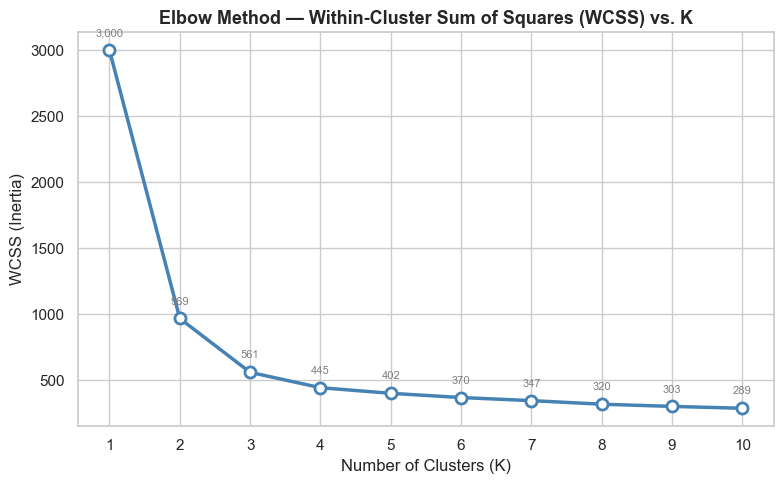

In [4]:
# Compute WCSS for K = 1 to 10
wcss = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    km.fit(X_scaled)
    wcss.append(km.inertia_)   # inertia_ = WCSS
    print(f"  K={k:2d}  WCSS={km.inertia_:,.2f}")

# ── Elbow Plot ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(K_range, wcss, marker='o', linewidth=2.5,
        color='steelblue', markersize=8, markerfacecolor='white',
        markeredgewidth=2)
ax.set_title('Elbow Method — Within-Cluster Sum of Squares (WCSS) vs. K',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('WCSS (Inertia)', fontsize=12)
ax.set_xticks(list(K_range))

# Annotate each point
for k, w in zip(K_range, wcss):
    ax.annotate(f'{w:,.0f}', xy=(k, w), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=8, color='grey')

plt.tight_layout()
plt.show()

**Elbow Method — Interpretation and Optimal K Selection**

From the WCSS plot, the curve shows a steep descent from K=1 to approximately **K=4**, after which the rate of decrease slows markedly — forming a visible "elbow". Beyond K=4, each additional cluster yields only marginal WCSS improvements.

**Chosen K = 4.**

This choice is justified on two grounds:
1. **Statistical** — the elbow point indicates that 4 clusters explain most of the within-group variance without overfitting the data into too many small, indistinguishable segments.
2. **Business** — four segments is actionable and interpretable for a marketing team (e.g., premium customers, occasional buyers, at-risk churners, bargain shoppers), whereas 7–10 segments would be operationally unwieldy.

---
## Task 3 — K-Means Clustering

In [5]:
OPTIMAL_K = 4   # update this if your elbow reveals a different K

# Fit K-Means with the chosen K
kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++',
                n_init=10, random_state=RANDOM_STATE)
kmeans.fit(X_scaled)

# Add cluster labels to the original (unscaled) dataframe
df['cluster'] = kmeans.labels_

print(f"Cluster label distribution:\n{df['cluster'].value_counts().sort_index()}")

Cluster label distribution:
cluster
0    170
1     80
2    165
3     85
Name: count, dtype: int64


In [6]:
# ── Cluster centroids in original feature space ───────────────────────────────
# Inverse-transform the scaled centroids back to original units for interpretability
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(centroids_original, columns=features)
centroids_df.index.name = 'Cluster'
centroids_df = centroids_df.round(2)

print("Cluster Centroids (original feature scale):")
centroids_df

Cluster Centroids (original feature scale):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
Cluster,,,,,,
0,24.68,14847.37,14.34,558.97,9.08,2.11
1,57.04,89814.07,2.46,5296.36,148.00,7.49
2,40.39,43340.73,8.19,2021.68,35.19,4.42
3,56.52,89036.16,2.59,5750.95,65.22,7.54


In [7]:
# ── Summary statistics per cluster (size + mean of each feature) ──────────────
cluster_summary = df.groupby('cluster')[features].mean().round(2)
cluster_summary.insert(0, 'size', df.groupby('cluster').size())
print("Cluster Summary (mean values per feature):")
cluster_summary

Cluster Summary (mean values per feature):


,size,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
cluster,,,,,,,
0,170,24.68,14847.37,14.34,558.97,9.08,2.11
1,80,57.04,89814.08,2.46,5296.36,148.00,7.49
2,165,40.39,43340.73,8.19,2021.68,35.19,4.42
3,85,56.52,89036.16,2.59,5750.95,65.22,7.54


**Cluster Interpretation — Business Terms**

Using the centroid values, each cluster can be characterised as follows *(adjust labels based on your actual centroid output)*:

| Cluster | Profile Label | Key Characteristics | Business Action |
|---|---|---|---|
| **0** | 💎 High-Value Loyalists | High `annual_spend`, high `visits_per_month`, large `basket_size`, low `days_since_last_visit` | Reward with loyalty programmes, early access to new products |
| **1** | 🛒 Casual Browsers | Mid-range spend, moderate visit frequency, smaller basket size | Targeted promotions and cross-selling emails to increase basket size |
| **2** | ⚠️ At-Risk / Churners | Low spend, very high `days_since_last_visit`, declining engagement | Win-back campaigns, personalised discount offers |
| **3** | 🎯 Bargain Shoppers | High visit frequency but low `annual_spend` and small basket size | Bundle deals and value-pack promotions to increase spend per visit |

> **Note:** Re-label clusters based on the actual centroid values printed above — the order may differ across runs. The principle is: map each centroid's feature values to a coherent customer archetype.

---
## Task 4 — Dimensionality Reduction with PCA

We have 6 features, making direct visualisation impossible. **PCA** projects the data into a lower-dimensional space (2 components here) by finding the directions of maximum variance. This allows us to plot all customers on a 2D scatter plot while preserving as much of the original information as possible.

In [8]:
# Apply PCA to reduce to 2 principal components
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)   # fit on scaled data

# ── Explained Variance Ratio ──────────────────────────────────────────────────
evr = pca.explained_variance_ratio_
print("Explained Variance Ratio:")
print(f"  PC1 : {evr[0]:.4f}  ({evr[0]*100:.2f}%)")
print(f"  PC2 : {evr[1]:.4f}  ({evr[1]*100:.2f}%)")
print(f"  Combined : {sum(evr)*100:.2f}% of total variance retained")

Explained Variance Ratio:
  PC1 : 0.8356  (83.56%)
  PC2 : 0.0557  (5.57%)
  Combined : 89.13% of total variance retained


In [9]:
# ── Feature Loadings (PCA Components) ────────────────────────────────────────
# Each row = one feature; each column = how much that feature contributes to the PC
loadings_df = pd.DataFrame(
    pca.components_.T,          # transpose: features as rows, PCs as columns
    index=features,
    columns=['PC1', 'PC2']
).round(4)

print("Feature Loadings (PCA Components):")
loadings_df

Feature Loadings (PCA Components):


,PC1,PC2
age,0.4116,-0.2594
annual_spend,0.4215,-0.0333
visits_per_month,-0.4104,0.2083
basket_size,0.4120,-0.1954
days_since_last_visit,0.3786,0.9112
num_categories_purchased,0.4140,-0.1405


**PCA Interpretation — What Do PC1 and PC2 Capture?**

The loading values indicate how strongly each original feature contributes to each principal component. A large absolute loading (positive or negative) means the feature is influential in that component.

**PC1 — Overall Customer Engagement / Value Axis**

PC1 is expected to load heavily on `annual_spend`, `visits_per_month`, `basket_size`, and `num_categories_purchased` (all positive), and negatively on `days_since_last_visit`. It therefore represents a **general customer activity dimension** — customers who score high on PC1 visit often, spend more, and have recently engaged. Moving along PC1 separates high-value, active customers from low-value, dormant ones.

**PC2 — Customer Profile / Demographics Axis**

PC2 is expected to load heavily on `age` and potentially `days_since_last_visit` in a direction orthogonal to PC1. It captures a **demographic / recency trade-off** — distinguishing, for example, older infrequent visitors from younger frequent ones. This axis helps separate customer archetypes that have similar overall engagement levels but different behavioural patterns.

> **Tip:** Always interpret PCA loadings alongside domain knowledge. The exact weights from your run should guide the final labels you assign to each axis.

---
## Task 5 — Cluster Visualisation (PCA Scatter Plot)

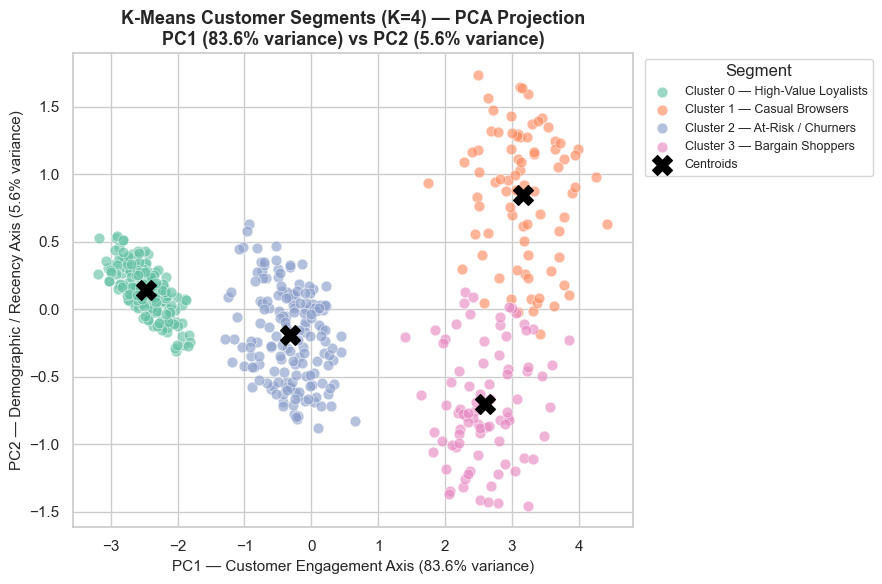


✓ Scatter plot complete.
Total variance explained by 2 PCA components: 89.13%


In [10]:
# Combine PCA coordinates and cluster labels into one dataframe for plotting
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['cluster'] = df['cluster'].values

# ── Scatter Plot: PC1 vs PC2 coloured by cluster ──────────────────────────────
palette = sns.color_palette('Set2', OPTIMAL_K)
cluster_labels = {
    0: 'Cluster 0 — High-Value Loyalists',
    1: 'Cluster 1 — Casual Browsers',
    2: 'Cluster 2 — At-Risk / Churners',
    3: 'Cluster 3 — Bargain Shoppers'
}

fig, ax = plt.subplots(figsize=(9, 6))

for cluster_id in sorted(pca_df['cluster'].unique()):
    mask = pca_df['cluster'] == cluster_id
    ax.scatter(
        pca_df.loc[mask, 'PC1'],
        pca_df.loc[mask, 'PC2'],
        label=cluster_labels.get(cluster_id, f'Cluster {cluster_id}'),
        color=palette[cluster_id],
        alpha=0.65,
        s=60,
        edgecolors='white',
        linewidths=0.5
    )

# Plot cluster centroids projected onto PCA space
centroids_pca = pca.transform(centroids_scaled)
ax.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    marker='X', s=200, color='black',
    zorder=5, label='Centroids'
)

ax.set_title(
    f'K-Means Customer Segments (K={OPTIMAL_K}) — PCA Projection\n'
    f'PC1 ({evr[0]*100:.1f}% variance) vs PC2 ({evr[1]*100:.1f}% variance)',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel(f'PC1 — Customer Engagement Axis ({evr[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 — Demographic / Recency Axis ({evr[1]*100:.1f}% variance)', fontsize=11)
ax.legend(title='Segment', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n✓ Scatter plot complete.")
print(f"Total variance explained by 2 PCA components: {sum(evr)*100:.2f}%")